# 03 - Modelagem Supervisionada de Atrasos

Modelos de classificação para prever atraso >15 minutos.

In [1]:
# Imports e carga da amostra
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

data = pd.read_parquet("../data/processed/flights_sample.parquet")
print(data.shape)

(300000, 21)


## 1. Seleção de features e alvo
Usamos apenas informações disponí­veis antes da decolagem para evitar vazamento.

In [2]:
# Seleciona features conhecidas antes da decolagem e o alvo DELAYED
features = ["AIRLINE","ORIGIN_AIRPORT","DESTINATION_AIRPORT","MONTH","DAY_OF_WEEK","DEP_HOUR","DISTANCE","IS_WEEKEND"]
X = data[features]
y = data["DELAYED"]

cat_features = ["AIRLINE","ORIGIN_AIRPORT","DESTINATION_AIRPORT"]
num_features = ["MONTH","DAY_OF_WEEK","DEP_HOUR","DISTANCE","IS_WEEKEND"]

## 2. Divisão treino/teste estratificada

In [3]:
# Split estratificado para manter proporcao da classe de atraso
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((240000, 8), (60000, 8))

## 3. Pipeline de pré-processamento
- Imputação para robustez.
- One-hot para categóricas.
- Pass-through para numéricas.

In [4]:
# Pipelines de pre-processamento: imputacao e one-hot para categoricas, mediana para numericas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_features),
        ("num", numerical_transformer, num_features)
    ]
)

## 4. Baseline: Regressão Logí­stica (subamostra)

In [5]:
# Baseline: regressao logistica balanceada (subamostra para velocidade)
log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=300, n_jobs=-1, class_weight="balanced"))
])

X_train_lr = X_train.sample(n=100_000, random_state=42)
y_train_lr = y_train.loc[X_train_lr.index]

log_reg.fit(X_train_lr, y_train_lr)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

C:\Users\cleit\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.88      0.58      0.70     49323
           1       0.24      0.62      0.35     10677

    accuracy                           0.59     60000
   macro avg       0.56      0.60      0.52     60000
weighted avg       0.76      0.59      0.64     60000

ROC-AUC: 0.6338049531197512


C:\Users\cleit\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Modelo principal: Random Forest

In [6]:
# Modelo principal: Random Forest balanceado no treino completo
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=120, max_depth=16, random_state=42, n_jobs=-1, class_weight="balanced"
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.88      0.63      0.73     49323
           1       0.25      0.59      0.35     10677

    accuracy                           0.62     60000
   macro avg       0.56      0.61      0.54     60000
weighted avg       0.76      0.62      0.66     60000

ROC-AUC: 0.6451370646309768


## 6. Avaliacao e threshold
Relatorios abaixo mostram o desempenho com corte padrao (0.5) e, em seguida, o threshold que maximiza F1 da classe de atraso. O objetivo eh ganhar recall da classe 1 mesmo perdendo um pouco de acuracia.


In [7]:
# Ajuste de threshold maximizando F1 da classe de atraso
prec, rec, thresh = precision_recall_curve(y_test, y_proba_rf)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresh[best_idx]
print(f"Melhor threshold (F1 classe 1): {best_threshold:.3f}")
y_pred_rf_thresh = (y_proba_rf >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_rf_thresh))


Melhor threshold (F1 classe 1): 0.496
              precision    recall  f1-score   support

           0       0.88      0.59      0.71     49323
           1       0.25      0.62      0.35     10677

    accuracy                           0.60     60000
   macro avg       0.56      0.61      0.53     60000
weighted avg       0.77      0.60      0.65     60000



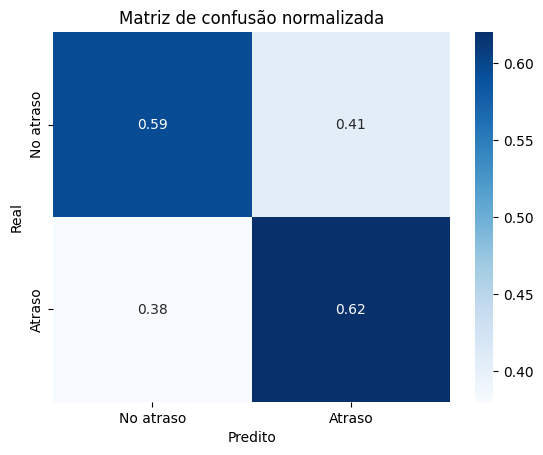

In [8]:
# Matriz de confusao usando predicoes com threshold ajustado
cm = confusion_matrix(y_test, y_pred_rf_thresh, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=["No atraso","Atraso"], yticklabels=["No atraso","Atraso"])
plt.title("Matriz de confusão normalizada")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

### Conclusoes
- Regressao logistica (class_weight, treino em 100k): ROC-AUC ~0.634; precisao ~0.24 / recall ~0.62 / acc ~0.59; houve aviso de convergencia do solver.
- Random Forest (class_weight): ROC-AUC ~0.645; corte padrao 0.5 entrega precisao ~0.25 / recall ~0.59 / acc ~0.62; threshold otimo ~0.496 sobe recall para ~0.62 com precisao ~0.25 (acc ~0.60).
- Para melhorar: calibrar probabilidades, fazer tuning mais amplo e testar modelos como XGBoost ou mais features de contexto.
